In [1]:
import pandas as pd
from joblib import load
from sklearn.metrics import f1_score,confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [2]:
shap_background = 50

oxide = pd.read_excel(r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\new random comp generator\GEOROC data\processed minerals\oxide_data.xlsx", sheet_name="Sheet1",index_col=0,header=0)

def normalize(data,n=100):
    s = n/data.sum(axis=1)
    data_formatted = data.mul(s,axis=0)
    return(data_formatted)
    
def wt_to_mol(data, oxide = oxide):
    data[data<=2] = 0
    if 'Total' in data.columns:
        data.pop('Total')
    oxlist1 = data.columns
    oxide = oxide.T[oxlist1].iloc[0, :]
    data = normalize(data,100)
    data_f = data.div(oxide,axis=1)
    data_f = normalize(data_f)
    return(data_f.round(2))

# file = r"D:/Research/Mineral identifier ann IISER Mohali/new random comp generator/GEOROC data/processed minerals/molar tables/new data/compiled9_2.xlsx"
# file_test = r"D:/Research/Mineral identifier ann IISER Mohali/new random comp generator/External test data/Mineral data combined_RSandSS_mol1.xlsx"
# file_test = r"D:\Research\Mineral identifier ann IISER Mohali\new random comp generator\External test data\Mineral data combined_DHZ,PSandSS.xlsx"
# file_test = r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\ms and reference papers\MinNet ver 4 for submitted to AmMin\Revision 1\AmMin revision 1\Sir modified files\External dataset 2\Processed\name shortened\Combined_PantSir.xlsx"
# file_test = r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\Datasets\Qmin testing\combinedPantSirforMinNet_C3.xlsx"
file_test = r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\Datasets\External dataset\Test_data_combined2.xlsx"

# data = pd.read_excel(file,header=0,index_col=0)
data_test = pd.read_excel(file_test,header=0,index_col=0)
m = len(data_test['Mineral'].unique())
acc_table = np.zeros((m+1,5))

data_test

,Mineral,Source,SiO2,MgO,FeO,TiO2,Al2O3,MnO,CaO,Na2O,...,Dy2O3,Er2O3,Yb2O3,V2O3,CoO,ZrO2,CuO,CO2,SnO,Total
0,Amp,"Carpenter, P., Irving, A., & Jolliff, B. (2021...",35.670,1.160,30.900,0.440,10.690,0.360,10.230,1.070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93.900
1,Amp,"Carpenter, P., Irving, A., & Jolliff, B. (2021...",37.480,0.970,31.950,0.380,8.620,0.360,9.230,0.760,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,92.450
2,Amp,"Carpenter, P., Irving, A., & Jolliff, B. (2021...",35.600,0.710,32.700,0.240,10.400,0.210,10.100,0.940,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94.670
3,Amp,"Carpenter, P., Irving, A., & Jolliff, B. (2021...",50.100,23.190,0.770,1.000,6.610,0.060,11.760,3.760,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,98.190
4,Amp,"Carpenter, P., Irving, A., & Jolliff, B. (2021...",49.700,22.800,1.080,0.630,5.890,0.080,11.400,3.880,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Bt,"Baswani, S. R., Mishra, B. P., Mahapatro, S. N...",34.725,7.409,23.322,2.037,15.399,0.330,0.000,0.170,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57.869
67,Bt,"Baswani, S. R., Mishra, B. P., Mahapatro, S. N...",35.632,7.156,24.104,2.282,15.782,0.423,0.000,0.108,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59.131
68,Bt,"Baswani, S. R., Mishra, B. P., Mahapatro, S. N...",35.100,7.338,23.737,1.939,15.777,0.275,0.000,0.067,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,58.342
69,Bt,"Baswani, S. R., Mishra, B. P., Mahapatro, S. N...",35.152,7.355,23.903,2.199,15.868,0.312,0.000,0.137,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,58.991


In [3]:
len(data_test['Mineral'].unique())

18

In [4]:
data_test.groupby(by="Mineral").count()

,Source,SiO2,MgO,FeO,TiO2,Al2O3,MnO,CaO,Na2O,K2O,...,Dy2O3,Er2O3,Yb2O3,V2O3,CoO,ZrO2,CuO,CO2,SnO,Total
Mineral,,,,,,,,,,,,,,,,,,,,,
Als,10,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,10,10,10
Amp,203,203,203,203,203,203,203,203,203,203,...,203,203,203,203,203,203,203,203,203,203
Ap,136,136,136,136,136,136,136,136,136,136,...,136,136,136,136,136,136,136,136,136,136
Bt,548,548,548,548,548,548,548,548,548,548,...,548,548,548,548,548,548,548,548,548,548
Cb,39,39,39,39,39,39,39,39,39,39,...,39,39,39,39,39,39,39,39,39,39
Crd,157,157,157,157,157,157,157,157,157,157,...,157,157,157,157,157,157,157,157,157,157
Fsp,428,428,428,428,428,428,428,428,428,428,...,428,428,428,428,428,428,428,428,428,428
Grt,326,326,326,326,326,326,326,326,326,326,...,326,326,326,326,326,326,326,326,326,326
Ilm,126,126,126,126,126,126,126,126,126,126,...,126,126,126,126,126,126,126,126,126,126


In [5]:
data_test.columns

Index(['Mineral', 'Source', 'SiO2', 'MgO', 'FeO', 'TiO2', 'Al2O3', 'MnO',
       'CaO', 'Na2O', 'K2O', 'Cr2O3', 'P2O5', 'NiO', 'Fe2O3', 'BaO', 'ZnO',
       'F', 'Cl', 'As2O3', 'SrO', 'Y2O3', 'La2O3', 'Ce2O3', 'Nd2O3', 'Pr2O3',
       'ThO2', 'UO2', 'Nb2O5', 'Sm2O3', 'Gd2O3', 'Dy2O3', 'Er2O3', 'Yb2O3',
       'V2O3', 'CoO', 'ZrO2', 'CuO', 'CO2', 'SnO', 'Total'],
      dtype='object')

In [6]:
if 'Mineral' in data_test.columns:
    minerals = data_test.pop("Mineral")
if 'Source' in data_test.columns:
    source = data_test.pop("Source")

# if 'Fe2O3' in data_test.columns:
#     data_test['FeO'] = data_test['FeO'] + (0.8998 * data_test['Fe2O3'])
    # data_test.pop('Fe2O3')
if 'F' in data_test.columns:
    data_test.pop('F')
if 'Cl' in data_test.columns:
    data_test.pop('Cl')

data_test = normalize(data_test)
metrics = 'macro'
samplemetrics = 'micro'
if 'Total' not in data_test.columns:
    data_test['Total'] = data_test.iloc[:,:-2].sum(axis=1)
# data_test.loc[minerals=='Cb','CO2'] = data_test['Total'] - data_test[['FeO','MnO','MgO','CaO']].sum(axis=1)

In [7]:
data_test.fillna(0,inplace=True)
data_test_original = data_test.copy()
data_test = data_test.round(2)

In [8]:
data_test.groupby(by=minerals).count()

,SiO2,MgO,FeO,TiO2,Al2O3,MnO,CaO,Na2O,K2O,Cr2O3,...,Dy2O3,Er2O3,Yb2O3,V2O3,CoO,ZrO2,CuO,CO2,SnO,Total
Mineral,,,,,,,,,,,,,,,,,,,,,
Als,10,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,10,10,10
Amp,203,203,203,203,203,203,203,203,203,203,...,203,203,203,203,203,203,203,203,203,203
Ap,136,136,136,136,136,136,136,136,136,136,...,136,136,136,136,136,136,136,136,136,136
Bt,548,548,548,548,548,548,548,548,548,548,...,548,548,548,548,548,548,548,548,548,548
Cb,39,39,39,39,39,39,39,39,39,39,...,39,39,39,39,39,39,39,39,39,39
Crd,157,157,157,157,157,157,157,157,157,157,...,157,157,157,157,157,157,157,157,157,157
Fsp,428,428,428,428,428,428,428,428,428,428,...,428,428,428,428,428,428,428,428,428,428
Grt,326,326,326,326,326,326,326,326,326,326,...,326,326,326,326,326,326,326,326,326,326
Ilm,126,126,126,126,126,126,126,126,126,126,...,126,126,126,126,126,126,126,126,126,126


In [9]:
data_test = wt_to_mol(data_test,oxide)
# if 'SrO' in data_test.columns:
#     data_test['CaO'] = data_test['CaO'] + data_test['SrO']
#     data_test.pop('SrO')
# if 'BaO' in data_test.columns:
#     data_test['CaO'] = data_test['CaO'] + data_test['BaO']
#     data_test.pop('BaO')
# if 'Cr2O3' in data_test.columns:
#     data_test['Al2O3'] = data_test['Al2O3'] + data_test['Cr2O3']
#     data_test.pop('Cr2O3')
# if 'ZnO' in data_test.columns:
#     data_test['FeO'] = data_test['FeO'] + data_test['ZnO']
#     data_test.pop('ZnO')
# if 'CoO' in data_test.columns:
#     data_test['FeO'] = data_test['FeO'] + data_test['CoO']
#     data_test.pop('CoO')
# if 'Fe2O3' in data_test.columns:
#     data_test['Al2O3'] = data_test['Al2O3'] + data_test['Fe2O3']
#     data_test.pop('Fe2O3')

# # data_test = normalized(data_test[['SiO2

In [94]:
data_test.groupby(by=minerals).count()

,SiO2,MgO,FeO,TiO2,Al2O3,MnO,CaO,Na2O,K2O,Cr2O3,...,Gd2O3,Dy2O3,Er2O3,Yb2O3,V2O3,CoO,ZrO2,CuO,CO2,SnO
Mineral,,,,,,,,,,,,,,,,,,,,,
Als,10,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,10,10,10
Amp,203,203,203,203,203,203,203,203,203,203,...,203,203,203,203,203,203,203,203,203,203
Ap,136,136,136,136,136,136,136,136,136,136,...,136,136,136,136,136,136,136,136,136,136
Bt,548,548,548,548,548,548,548,548,548,548,...,548,548,548,548,548,548,548,548,548,548
Cb,39,39,39,39,39,39,39,39,39,39,...,39,39,39,39,39,39,39,39,39,39
Crd,157,157,157,157,157,157,157,157,157,157,...,157,157,157,157,157,157,157,157,157,157
Fsp,428,428,428,428,428,428,428,428,428,428,...,428,428,428,428,428,428,428,428,428,428
Grt,326,326,326,326,326,326,326,326,326,326,...,326,326,326,326,326,326,326,326,326,326
Ilm,126,126,126,126,126,126,126,126,126,126,...,126,126,126,126,126,126,126,126,126,126


# Raw Input (C1)

In [95]:
model = load("KNN_C1.mdl")
scaler = load("Scaler_C1.scl")
labeler = load("Labeler_C1.lbl")

data_test1 = data_test.copy()
# data_test1['M'] = data_test1[["FeO","MnO","MgO"]].sum(axis=1)
colnames_raw = ['SiO2','TiO2','Al2O3','FeO','MnO','MgO','CaO','Na2O','K2O','P2O5','CO2']
data_test1 = normalize(data_test1[colnames_raw])

# m = data_test1[["FeO","MnO","MgO"]]sum(axis=1)

data_test_scaled = scaler.transform(data_test1)
test_target = labeler.transform(minerals)
pred_label = model.predict(data_test_scaled)
a = round(f1_score(test_target, pred_label, average=metrics,zero_division=0),4)*100
acc_table[0,0] = a
print("Overall: "+str(a))

labels = labeler.transform(minerals.unique())
labels1 = labeler.inverse_transform(labels)

for n,i in enumerate(labels1):
    data_test2 = scaler.transform(data_test1.loc[minerals==i,:])
    minerals2 = labeler.transform(minerals.loc[minerals == i])
    pred_label2 = model.predict(data_test2)
    a = round(f1_score(minerals2, pred_label2, average=samplemetrics,zero_division=0),4)*100
    acc_table[n+1,0] = a

    print(labels1[n]+": "+str(round(a,2)))

data_mismatch = data_test.loc[test_target != pred_label,:]
minerals_mismatch = minerals.loc[test_target != pred_label]
data_mismatch = pd.concat([data_mismatch,minerals_mismatch],axis=1)
data_mismatch
f1_c1 = f1_score(minerals, labeler.inverse_transform(pred_label),average=None)

Overall: 91.75999999999999
Amp: 98.52
Ap: 100.0
Bt: 100.0
Crd: 100.0
Fsp: 87.15
Grt: 99.69
Ilm: 100.0
Mag/Hem: 100.0
Ms: 100.0
Ol: 99.08
Px: 93.23
Spl: 86.21
St: 100.0
Ttn: 100.0
Als: 100.0
Cb: 97.44
Qz: 100.0
Rt: 100.0


In [96]:
source[(minerals == "Amp") & ((labeler.inverse_transform(pred_label)) == "Px")]

86    Meeker, G. P., Bern, A. M., Brownfield, I. K.,...
99    Meeker, G. P., Bern, A. M., Brownfield, I. K.,...
13                                     unpublished data
Name: Source, dtype: object

In [97]:
labeler.classes_

array(['Als', 'Amp', 'Ap', 'Bt', 'Cb', 'Cor', 'Crd', 'Fsp', 'Grt', 'Ilm',
       'Mag/Hem', 'Ms', 'Ol', 'Px', 'Qz', 'Rt', 'Spl', 'St', 'Ttn'],
      dtype=object)

In [98]:
# import shap as sp
# # data_testing = data_test_scaled[test_target == 3]
# data_testing = data_test_scaled.copy()
# print(data_testing)
# explainer = sp.KernelExplainer(model.predict,sp.sample(data_testing,shap_background))
# # shap_values = explainer.shap_values(sp.sample(data_testing,50))
# # shap_values1 = explainer(sp.sample(data_testing,100))
# shap_values1_raw = explainer(data_testing[:,:])

# # shap_values2 = explainer.shap_values(data_testing[0:50,:],nsamples=100)

In [99]:
# #OLivine
# sol = minerals_c4[minerals_c4 == "Ol"].index.values
# print(sol)
# # print(sgrt)
# sp.summary_plot(shap_values=shap_values_raw[sol,:],feature_names=colnames_raw)
# # sp.summary_plot(shap_values=shap_values_raw[sol,:],feature_names=colnames_raw)
# # sp.summary_plot(shap_values=shap_values1[1371:1376,:],feature_names=data_test.columns)

In [100]:
print(classification_report(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label)))

              precision    recall  f1-score   support

         Als       1.00      1.00      1.00        10
         Amp       0.89      0.99      0.93       203
          Ap       1.00      1.00      1.00       136
          Bt       1.00      1.00      1.00       548
          Cb       1.00      0.97      0.99        39
         Cor       0.00      0.00      0.00         0
         Crd       0.99      1.00      1.00       157
         Fsp       1.00      0.87      0.93       428
         Grt       0.97      1.00      0.98       326
         Ilm       1.00      1.00      1.00       126
     Mag/Hem       1.00      1.00      1.00        78
          Ms       0.57      1.00      0.73        60
          Ol       1.00      0.99      1.00       217
          Px       0.97      0.93      0.95       458
          Qz       1.00      1.00      1.00         2
          Rt       1.00      1.00      1.00         4
         Spl       1.00      0.86      0.93        58
          St       1.00    

C:\Users\naik3\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\naik3\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\naik3\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

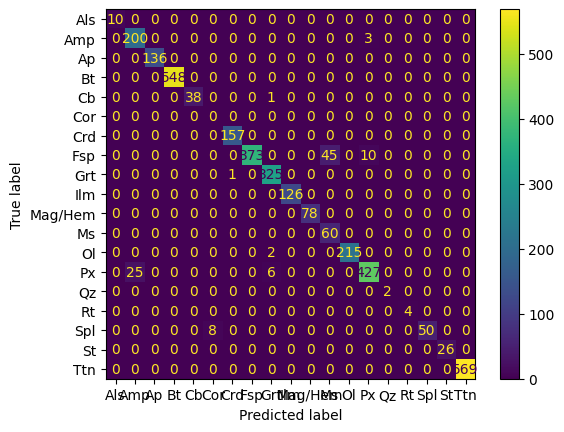

In [101]:
ConfusionMatrixDisplay.from_predictions(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label))

In [102]:
if 'SrO' in data_test.columns:
    data_test['CaO'] = data_test['CaO'] + data_test['SrO']
    data_test.pop('SrO')
if 'BaO' in data_test.columns:
    data_test['CaO'] = data_test['CaO'] + data_test['BaO']
    data_test.pop('BaO')
if 'Cr2O3' in data_test.columns:
    data_test['Al2O3'] = data_test['Al2O3'] + data_test['Cr2O3']
    data_test.pop('Cr2O3')
if 'ZnO' in data_test.columns:
    data_test['FeO'] = data_test['FeO'] + data_test['ZnO']
    data_test.pop('ZnO')
if 'CoO' in data_test.columns:
    data_test['FeO'] = data_test['FeO'] + data_test['CoO']
    data_test.pop('CoO')
if 'Fe2O3' in data_test.columns:
    data_test['Al2O3'] = data_test['Al2O3'] + data_test['Fe2O3']
    data_test.pop('Fe2O3')

# data_test = normalized(data_test[['SiO2

# C2

In [103]:
data_test.columns

Index(['SiO2', 'MgO', 'FeO', 'TiO2', 'Al2O3', 'MnO', 'CaO', 'Na2O', 'K2O',
       'P2O5', 'NiO', 'As2O3', 'Y2O3', 'La2O3', 'Ce2O3', 'Nd2O3', 'Pr2O3',
       'ThO2', 'UO2', 'Nb2O5', 'Sm2O3', 'Gd2O3', 'Dy2O3', 'Er2O3', 'Yb2O3',
       'V2O3', 'ZrO2', 'CuO', 'CO2', 'SnO'],
      dtype='object')

In [104]:
model = load("KNN_C2.mdl")
scaler = load("Scaler_C2.scl")
labeler = load("Labeler_C2.lbl")

data_test1 = data_test.copy()
data_test1['M'] = data_test1[["FeO","MnO","MgO"]].sum(axis=1)
data_test1 = normalize(data_test1[['SiO2','TiO2','Al2O3','M','CaO','Na2O','K2O','P2O5','CO2']])

# m = data_test1[["FeO","MnO","MgO"]]sum(axis=1)

data_test_scaled = scaler.transform(data_test1)
test_target = labeler.transform(minerals)
pred_label = model.predict(data_test_scaled)
a = round(f1_score(test_target, pred_label, average=metrics,zero_division=0),4)*100
acc_table[0,1] = a
print("Overall: "+str(a))

labels = labeler.transform(minerals.unique())
labels1 = labeler.inverse_transform(labels)

for n,i in enumerate(labels1):
    data_test2 = scaler.transform(data_test1.loc[minerals==i,:])
    minerals2 = labeler.transform(minerals.loc[minerals == i])
    pred_label2 = model.predict(data_test2)
    a = round(f1_score(minerals2, pred_label2, average=samplemetrics,zero_division=0),4)*100
    acc_table[n+1,1] = a
    print(labels1[n]+": "+str(round(a,2)))

data_mismatch = data_test.loc[test_target != pred_label,:]
minerals_mismatch = minerals.loc[test_target != pred_label]
data_mismatch = pd.concat([data_mismatch,minerals_mismatch],axis=1)
# data_mismatch['Pred'] = labeler.inverse_transform(pred_label)
f1_c2 = f1_score(minerals, labeler.inverse_transform(pred_label),average=None)

Overall: 97.61999999999999
Amp: 97.54
Ap: 100.0
Bt: 100.0
Crd: 100.0
Fsp: 87.62
Grt: 100.0
Ilm: 100.0
Mag/Hem: 100.0
Ms: 100.0
Ol: 100.0
Px: 95.63
Spl: 100.0
St: 100.0
Ttn: 100.0
Als: 100.0
Cb: 100.0
Qz: 100.0
Rt: 100.0


In [105]:
print(classification_report(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label)))

              precision    recall  f1-score   support

         Als       1.00      1.00      1.00        10
         Amp       0.91      0.98      0.94       203
          Ap       1.00      1.00      1.00       136
          Bt       1.00      1.00      1.00       548
          Cb       1.00      1.00      1.00        39
         Crd       1.00      1.00      1.00       157
         Fsp       1.00      0.88      0.93       428
         Grt       1.00      1.00      1.00       326
         Ilm       1.00      1.00      1.00       126
     Mag/Hem       1.00      1.00      1.00        78
          Ms       0.58      1.00      0.74        60
          Ol       1.00      1.00      1.00       217
          Px       0.97      0.96      0.96       458
          Qz       1.00      1.00      1.00         2
          Rt       1.00      1.00      1.00         4
         Spl       1.00      1.00      1.00        58
          St       1.00      1.00      1.00        26
         Ttn       1.00    

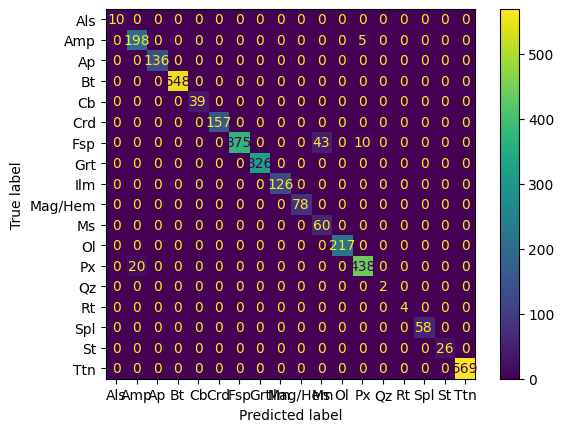

In [106]:
ConfusionMatrixDisplay.from_predictions(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label))

In [107]:
source[(minerals == "Amp") & ((labeler.inverse_transform(pred_label)) == "Grt")]

Series([], Name: Source, dtype: object)

In [108]:
# import shap as sp
# # data_testing = data_test_scaled[test_target == 3]
# data_testing = data_test_scaled.copy()
# explainer = sp.KernelExplainer(model.predict,sp.sample(data_testing,shap_background))
# #shap_values = explainer.shap_values(sp.sample(data_testing,50))
# shap_values1 = explainer(data_testing)


In [109]:
#shap_values1

In [110]:
# sp.plots.beeswarm(shap_values=shap_values1)

# C3

In [111]:
model = load("KNN_C3.mdl")
scaler = load("Scaler_C3.scl")
labeler = load("Labeler_C3.lbl")

data_test1 = data_test.copy()
data_test1['M'] = data_test1[["FeO","MnO","MgO"]].sum(axis=1)
data_test1['A'] = data_test1[["Na2O","K2O"]].sum(axis=1)
colnames = ['SiO2','TiO2','Al2O3','M','CaO','A','P2O5','CO2']
data_test1 = normalize(data_test1[colnames])

# m = data_test1[["FeO","MnO","MgO"]]sum(axis=1)

data_test_scaled = scaler.transform(data_test1)
test_target = labeler.transform(minerals)
pred_label = model.predict(data_test_scaled)
a = round(f1_score(test_target, pred_label, average=metrics,zero_division=0),4)*100
acc_table[0,2] = a
print("Overall: "+str(a))

labels = labeler.transform(minerals.unique())
labels1 = labeler.inverse_transform(labels)

for n,i in enumerate(labels1):
    data_test2 = scaler.transform(data_test1.loc[minerals==i,:])
    minerals2 = labeler.transform(minerals.loc[minerals == i])
    pred_label2 = model.predict(data_test2)
    a = round(f1_score(minerals2, pred_label2, average=samplemetrics,zero_division=0),4)*100
    acc_table[n+1,2] = a
    print(labels1[n]+": "+str(round(a,2)))

data_mismatch = data_test.loc[test_target != pred_label,:]
data_mismatch1 = data_test_original.loc[test_target != pred_label,:]
minerals_mismatch = minerals.loc[test_target != pred_label]
data_mismatch = pd.concat([data_mismatch1,minerals_mismatch],axis=1)
data_mismatch['Source'] = source.loc[test_target != pred_label]
f1_c3 = f1_score(minerals, labeler.inverse_transform(pred_label),average=None)

Overall: 99.53999999999999
Amp: 98.03
Ap: 100.0
Bt: 100.0
Crd: 100.0
Fsp: 100.0
Grt: 100.0
Ilm: 100.0
Mag/Hem: 100.0
Ms: 100.0
Ol: 100.0
Px: 95.63
Spl: 100.0
St: 100.0
Ttn: 100.0
Als: 100.0
Cb: 100.0
Qz: 100.0
Rt: 100.0


In [112]:
data_test_mismatch = data_test.copy()
data_mismatch = data_test_mismatch[minerals != labeler.inverse_transform(pred_label)]
data_mismatch["Mineral"] = minerals[minerals != labeler.inverse_transform(pred_label)]

C:\Users\naik3\AppData\Local\Temp\ipykernel_1384\1553703512.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_mismatch["Mineral"] = minerals[minerals != labeler.inverse_transform(pred_label)]


In [113]:
print(classification_report(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label)))

              precision    recall  f1-score   support

         Als       1.00      1.00      1.00        10
         Amp       0.91      0.98      0.94       203
          Ap       1.00      1.00      1.00       136
          Bt       1.00      1.00      1.00       548
          Cb       1.00      1.00      1.00        39
         Crd       1.00      1.00      1.00       157
         Fsp       1.00      1.00      1.00       428
         Grt       1.00      1.00      1.00       326
         Ilm       1.00      1.00      1.00       126
     Mag/Hem       1.00      1.00      1.00        78
          Ms       1.00      1.00      1.00        60
          Ol       1.00      1.00      1.00       217
          Px       0.99      0.96      0.97       458
          Qz       1.00      1.00      1.00         2
          Rt       1.00      1.00      1.00         4
         Spl       1.00      1.00      1.00        58
          St       1.00      1.00      1.00        26
         Ttn       1.00    

<Figure size 500x500 with 0 Axes>

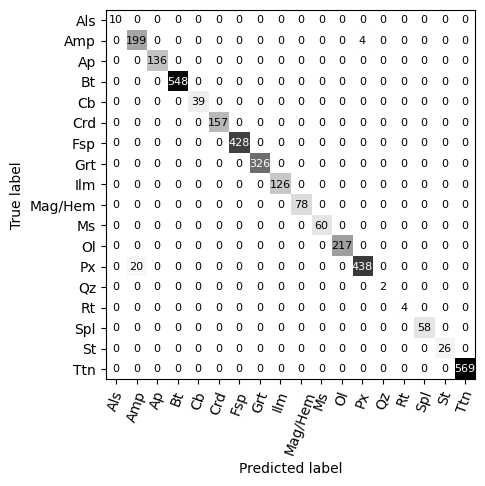

In [114]:
plt.figure(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label),
                                        text_kw={"size":8},im_kw={"cmap":"gray_r"},colorbar=False,xticks_rotation=70)
plt.savefig(r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\Datasets\Qmin testing\MinNet performance heatmap.pdf")

In [121]:
data_misclassified_Amp = data_test.loc[(minerals == "Px") & ((labeler.inverse_transform(pred_label)) == "Amp")]
data_misclassified_Amp.to_excel(r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\Datasets\External dataset\test_data_combined2_PxmisclassifiedasAmp.xlsx")

In [120]:
source[(minerals == "Amp") & ((labeler.inverse_transform(pred_label)) == "Px")]

86    Meeker, G. P., Bern, A. M., Brownfield, I. K.,...
90    Meeker, G. P., Bern, A. M., Brownfield, I. K.,...
91    Meeker, G. P., Bern, A. M., Brownfield, I. K.,...
99    Meeker, G. P., Bern, A. M., Brownfield, I. K.,...
Name: Source, dtype: object

In [33]:
# data_testing1 = data_test[(minerals == "Amp") & (labeler.inverse_transform(pred_label) == "Px")]
# data_testing1.to_excel(r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\Datasets\Qmin testing\PantSirCombinedDataset_Ampmisclassification1.xlsx")
# data_testing1

In [34]:
# import shap as sp
# # data_testing = data_test_scaled[test_target == 3]
# data_testing = data_test_scaled.copy()
# print(data_testing)
# explainer = sp.KernelExplainer(model.predict,sp.sample(data_testing,shap_background))
# # shap_values = explainer.shap_values(sp.sample(data_testing,50))
# # shap_values1 = explainer(sp.sample(data_testing,100))
# shap_values_c3 = explainer(data_testing[:,:])
# # shap_values2 = explainer.shap_values(data_testing[0:50,:],nsamples=100)

In [35]:
# import shap as sp
# # data_testing = data_test_scaled[test_target == 3]
# data_testing = data_test_scaled[(minerals == "Ol") | (minerals == "Px")].copy()
# mins = minerals[(minerals == "Ol") | (minerals == "Px")].copy()
# explainer = sp.KernelExplainer(model.predict,sp.sample(data_testing,shap_background))
# # shap_values = explainer.shap_values(sp.sample(data_testing,50))
# # shap_values1 = explainer(sp.sample(data_testing,100))
# shap_values_c3 = explainer(data_testing[:,:])
# # shap_values2 = explainer.shap_values(data_testing[0:50,:],nsamples=100)

In [36]:
# shap_values_c3.sample(1)

In [37]:
# sol = data_test[minerals == "Amp"].index.values
# # print(sgrt)
# sp.summary_plot(shap_values=shap_values_c3[sol,:],feature_names=colnames)

In [38]:
# import shap as sp
# min1 = "Amp"
# min2 = "Px"
# data_testing = data_test_scaled[(minerals == min1) | (minerals == min2)].copy()
# mins = minerals[(minerals == "Amp") | (minerals == "Grt")].copy()
# explainer = sp.KernelExplainer(model.predict,sp.sample(data_testing,300))
# shap_values_c3 = explainer(data_testing[:,:])

In [39]:
# np.shape(data_testing)

In [40]:
# sol = list(np.where(mins == "Px"))[0]
# print(sol)
# sp.summary_plot(shap_values=shap_values_c3[sol,:],feature_names=colnames)

In [41]:
# x = 1050
# print(minerals[x])

# plt.subplot(121)
# sp.bar_plot(shap_values_raw.values[x,:],feature_names=colnames_raw)

# plt.subplot(122)
# sp.bar_plot(shap_values_c3.values[x,:],feature_names=colnames)


# C4

In [42]:
model = load("KNN_C4.mdl")
scaler = load("Scaler_C4.scl")
labeler = load("Labeler_C4.lbl")

data_test1 = data_test.copy()
data_test1['M'] = data_test1[["FeO","MnO","MgO","CaO"]].sum(axis=1)
data_test1['A'] = data_test1[["CaO","Na2O","K2O"]].sum(axis=1)
colnames_c4 = ['SiO2','TiO2','Al2O3','M','A','P2O5','CO2']
data_test1 = normalize(data_test1[colnames_c4])

# m = data_test1[["FeO","MnO","MgO"]]sum(axis=1)

data_test_scaled = scaler.transform(data_test1)
test_target = labeler.transform(minerals)
pred_label = model.predict(data_test_scaled)
a = round(f1_score(test_target, pred_label, average=metrics,zero_division=0),4)*100
acc_table[0,3] = a
print("Overall: "+str(a))

labels = labeler.transform(minerals.unique())
labels1 = labeler.inverse_transform(labels)

for n,i in enumerate(labels1):
    data_test2 = scaler.transform(data_test1.loc[minerals==i,:])
    minerals2 = labeler.transform(minerals.loc[minerals == i])
    pred_label2 = model.predict(data_test2)
    a = round(f1_score(minerals2, pred_label2, average=samplemetrics,zero_division=0),4)*100
    acc_table[n+1,3] = a
    print(labels1[n]+": "+str(round(a,2)))

data_mismatch = data_test.loc[test_target != pred_label,:]
minerals_mismatch = minerals.loc[test_target != pred_label]
data_mismatch = pd.concat([data_mismatch,minerals_mismatch],axis=1)
f1_c4 = f1_score(minerals, labeler.inverse_transform(pred_label),average=None)

Overall: 81.94
Amp: 33.0
Ap: 0.74
Bt: 99.82
Crd: 99.36
Fsp: 78.97
Grt: 78.22
Ilm: 100.0
Mag/Hem: 100.0
Ms: 91.67
Ol: 99.54
Px: 38.65
Spl: 100.0
St: 100.0
Ttn: 74.52
Als: 100.0
Cb: 100.0
Qz: 100.0
Rt: 100.0


In [43]:
print(classification_report(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label)))

              precision    recall  f1-score   support

         Als       1.00      1.00      1.00        10
         Amp       0.21      0.33      0.25       203
          Ap       1.00      0.01      0.01       136
          Bt       0.58      1.00      0.73       548
          Cb       1.00      1.00      1.00        39
         Crd       0.78      0.99      0.88       157
         Fsp       0.99      0.79      0.88       428
         Grt       1.00      0.78      0.88       326
         Ilm       1.00      1.00      1.00       126
     Mag/Hem       1.00      1.00      1.00        78
          Ms       0.73      0.92      0.81        60
          Ol       1.00      1.00      1.00       217
          Px       0.98      0.39      0.55       458
          Qz       1.00      1.00      1.00         2
          Rt       1.00      1.00      1.00         4
         Spl       1.00      1.00      1.00        58
          St       1.00      1.00      1.00        26
         Ttn       0.76    

In [44]:
# import shap as sp
# # data_testing = data_test_scaled[test_target == 3]
# data_testing = data_test_scaled.copy()
# explainer = sp.KernelExplainer(model.predict,sp.sample(data_testing,shap_background))
# #shap_values = explainer.shap_values(sp.sample(data_testing,50))
# shap_values_c4 = explainer(data_testing)

In [45]:
# model.n_classes_

In [46]:
# sp.summary_plot(shap_values=shap_values_c4,feature_names=colnames_c4)

In [47]:
# # spl = data_test[minerals == "Ttn"].index.values
# # print(sgrt)
# sp.summary_plot(shap_values=shap_values_c4[spl,:],feature_names=colnames_c4)

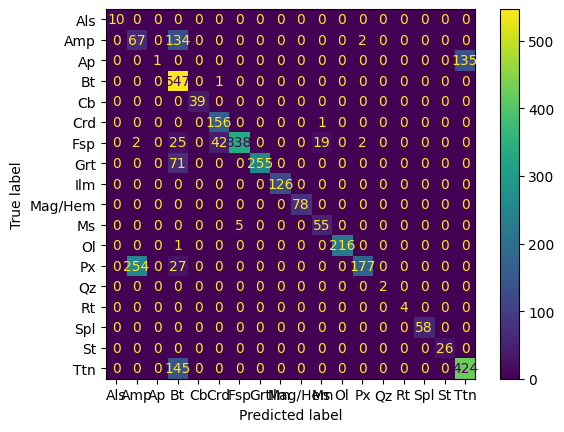

In [48]:
ConfusionMatrixDisplay.from_predictions(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label))

# C5

In [49]:
model = load("KNN_C5_5_components.mdl")
scaler = load("Scaler_C5_5_components.scl")
labeler = load("Labeler_C5_5_components.lbl")
pc = load("PCA_C5_5_components.pc")

# model = load("KNN_C5_6_components.mdl")
# scaler = load("Scaler_C5_6_components.scl")
# labeler = load("Labeler_C5_6_components.lbl")
# pc = load("PCA_C5_6_components.pc")

data_test1 = data_test.copy()
data_test1 = normalize(data_test1[['SiO2','TiO2','Al2O3','FeO','MnO','MgO','CaO','Na2O','K2O','P2O5','CO2']])
# m = data_test1[["FeO","MnO","MgO"]]sum(axis=1)

data_test_scaled = scaler.transform(data_test1)
data_test_scaled = pc.transform(data_test_scaled)
test_target = labeler.transform(minerals)
pred_label = model.predict(data_test_scaled)
a = round(f1_score(test_target, pred_label, average=metrics,zero_division=0),4)*100
acc_table[0,4] = a
print("Overall: "+str(a))

labels = labeler.transform(minerals.unique())
labels1 = labeler.inverse_transform(labels)

for n,i in enumerate(labels1):
    data_test2 = scaler.transform(data_test1.loc[minerals==i,:])
    data_test2 = pc.transform(data_test2)
    minerals2 = labeler.transform(minerals.loc[minerals == i])
    pred_label2 = model.predict(data_test2)
    a = round(f1_score(minerals2, pred_label2, average=samplemetrics,zero_division=0),4)*100
    acc_table[n+1,4] = a
    print(labels1[n]+": "+str(round(a,2)))

data_mismatch = data_test.loc[test_target != pred_label,:]
minerals_mismatch = minerals.loc[test_target != pred_label]
data_mismatch = pd.concat([data_mismatch,minerals_mismatch],axis=1)
f1_c5 = f1_score(minerals, labeler.inverse_transform(pred_label),average=None)

Overall: 97.28
Amp: 97.04
Ap: 100.0
Bt: 99.82
Crd: 100.0
Fsp: 93.93
Grt: 99.69
Ilm: 100.0
Mag/Hem: 100.0
Ms: 100.0
Ol: 99.08
Px: 93.67
Spl: 100.0
St: 100.0
Ttn: 100.0
Als: 100.0
Cb: 97.44
Qz: 100.0
Rt: 100.0


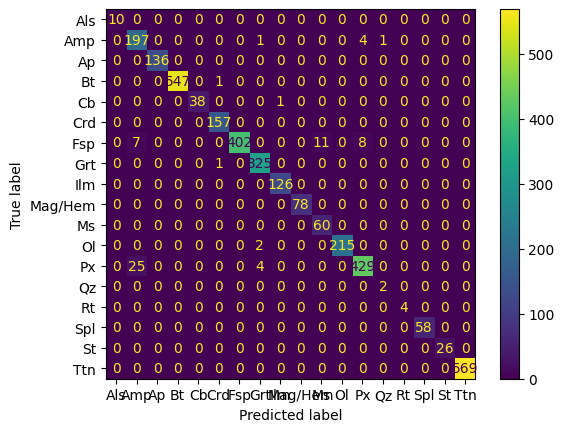

In [50]:
ConfusionMatrixDisplay.from_predictions(labeler.inverse_transform(test_target),labeler.inverse_transform(pred_label))

In [51]:
# import shap as sp
# #data_testing = data_test_scaled[test_target == 3]
# data_testing = data_test_scaled.copy()
# explainer = sp.KernelExplainer(model.predict,sp.sample(data_testing,shap_background))
# #shap_values = explainer.shap_values(sp.sample(data_testing,50))
# shap_values_c5 = explainer(data_testing)


In [52]:
shap_values1

NameError: name 'shap_values1' is not defined

In [ ]:
spl = data_test[minerals == "Fsp"].index.values
# print(sgrt)
sp.summary_plot(shap_values=shap_values_c5[spl,:],feature_names=colnames_c4)

In [ ]:
# sp.plots.beeswarm(shap_values=shap_values_c5)

In [53]:
f1_test = np.round(np.c_[f1_c1,f1_c2,f1_c3,f1_c4,f1_c5]*100,2)
# f1_test = pd.DataFrame(f1_test, index=

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 19 and the array at index 1 has size 18

In [ ]:
l=['Overall']
l.extend(list(minerals.unique()))
acc_table = pd.DataFrame(acc_table,
                          columns=["C1", "C2", "C3", "C4", "C5"],index=l)
acc_table.to_excel(r"C:\Users\naik3\Documents\Research\Mineral identifier ann IISER Mohali\Datasets\External dataset\F1-score Accuracy report for KNN_test on test_data.xlsx")


In [ ]:
print(classification_report(test_target,pred_label))